# Activity-adjusted P&B impact surface — sandbox

For a block of $N$ events with signed volume $Q$, gross volume $V$ and side $s=\mathrm{sign}(Q)$, let

- $z = |Q|/V$ (relative imbalance), $a = V/V_{24h}$ (relative activity: block volume over the preceding 24 h volume),
- $y = r/\sigma_{24h}$ (block log return over trailing 24 h realised volatility of the same bars; or the raw return).

$$\mathbb{E}[y \mid z,a,N,s] = s\,\mathcal{R}_N\,F\!\left(\frac{z\,a^{\gamma}}{\mathcal{Q}_N}\right),\qquad F(x)=\frac{x}{(1+|x|^{\alpha})^{\beta/\alpha}}.$$

$\gamma=1$ is the paper's P&B coordinate $|Q|/V_{24h}$; $\gamma=0$ is the plain imbalance ratio $|Q|/V$.

**Estimation** (`crypto_impact.pb_surface`): equal-count $z\times a$ cells per $N$ and side, monthly sufficient
statistics, geometric-mean cell representative, standard-error weights clipped to the 10–90% range per $N$,
soft-L1 loss, free $\mathcal{Q}_N,\mathcal{R}_N$ per $N$, shared $\alpha,\beta,\gamma$.
**Comparison metric:** weighted RMSE (residual / clipped SE). Scaled RMSE is not used because at $N=100$ only
$\mathcal{R}_N/\mathcal{Q}_N$ is identified.

Data: BTCUSDT `pb_blocks_v1` built from the shared `timestamp_direction_v1` events (`scripts/build_pb_blocks.py`).
**Nothing from 2026-09 onward may be used** (reserved for the alpha-search P-006 test); the loader refuses it.

This notebook is generated by `scripts/build_activity_surface_notebook.py` — edit the builder for permanent changes;
fiddle freely in the notebook itself.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
%matplotlib inline

PROJECT_DIR = Path.cwd().resolve()
if PROJECT_DIR.name == 'notebooks':
    PROJECT_DIR = PROJECT_DIR.parent
if not (PROJECT_DIR / 'src' / 'crypto_impact').exists():
    raise FileNotFoundError('Run from crypto-impact-study or its notebooks directory.')
REPO = PROJECT_DIR.parent
sys.path[:0] = [str(PROJECT_DIR / 'src'), str(PROJECT_DIR / 'scripts'), str(REPO / 'shared-methodology' / 'src')]

import run_activity_surface as run
from crypto_impact.pb_collapse import pb_shape, scaling_slope
from crypto_impact.pb_surface import (_clipped_sigma, aggregate_cells, fit_activity_surface,
                                      weighted_rmse)
from crypto_market_data.months import iter_months

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.4f}'.format)

## Knobs

Change these and rerun from here. Cell statistics are cached per (response, grid, sample), so changing
`RESPONSE`, `N_Z`/`N_A` or the sample window triggers one reload of the blocks (a few minutes for all N);
everything else (`N_USE`, `MIN_OBS`, sub-periods, fixed γ) refits from the cache in seconds.

In [2]:
N_ALL = run.N_VALUES                 # (100, 250, 500, 1000, 2000, 4000, 8000, 16000): blocks that exist
N_USE = N_ALL                        # subset used in the fits, e.g. (250, 1000, 4000, 16000)
RESPONSE = 'y_vol'                   # 'y_vol' = r / sigma_24h (primary); 'y' = raw log return
SAMPLE = ('2021-01', '2026-08')      # primary sample; ('2019-10', '2020-12') is the early robustness period
N_Z, N_A = 20, 10                    # equal-count bins in z and a (per N and side); run.N_Z, run.N_A = 20, 10
MIN_OBS = 100                        # minimum blocks per cell
N_STARTS = 8                         # optimiser starts for the headline fits

assert SAMPLE[1] <= '2026-08', 'Data from 2026-09 onward is reserved for the alpha-search P-006 test.'
CACHE = REPO / 'shared-data' / 'features' / 'academic' / 'symbol=BTCUSDT' / 'activity_surface_cells_v1'
REDO = PROJECT_DIR / 'reports' / 'redo' / 'activity_surface_2021_2026'

## Monthly cell statistics (cached)

Cuts are full-sample equal-count marginal quantiles of $z$ and $a$ for each $N$ and side (as in the redo's
full-sample fits). The cache holds, for every (N, side, z-bin, a-bin, month): count, Σy, Σy², Σlog z, Σlog a.
Any sub-sample or bootstrap is a sum over months.

In [3]:
def warm_up_month(start: str) -> str:
    # The 24h normalisations need the previous month loaded.
    year, month = map(int, start.split('-'))
    return f'{year - 1}-12' if month == 1 else f'{year}-{month - 1:02d}'


def cell_stats(n: int, response: str = RESPONSE, sample=SAMPLE, n_z: int = N_Z, n_a: int = N_A) -> pd.DataFrame:
    path = CACHE / f'{response}_{n_z}x{n_a}_{sample[0]}_{sample[1]}' / f'N={n}.parquet'
    if path.exists():
        return pd.read_parquet(path)
    arrays = run.load_arrays(REPO / 'shared-data', n, warm_up_month(sample[0]), sample[0], sample[1])
    old = run.N_Z, run.N_A
    run.N_Z, run.N_A = n_z, n_a
    try:
        stats = run.stats_for(arrays, n, None, response)
    finally:
        run.N_Z, run.N_A = old
    path.parent.mkdir(parents=True, exist_ok=True)
    stats.to_parquet(path, index=False)
    return stats


stats = pd.concat([cell_stats(n) for n in N_ALL], ignore_index=True)
MONTHS = np.array(sorted(stats['month'].unique()))
month_label = lambda m: f'{m // 12}-{m % 12 + 1:02d}'
print(f'{len(stats):,} monthly cell rows; months {month_label(MONTHS[0])}..{month_label(MONTHS[-1])}')
stats.groupby('n_events')['count'].sum().rename('blocks').to_frame().T

210,115 monthly cell rows; months 2021-01..2026-08


n_events,100,250,500,1000,2000,4000,8000,16000
blocks,23351943,9340769,4670391,2335196,1167599,583799,291899,145949


## Helpers

- `cells_for(...)`: aggregate monthly stats to cells for a month window / set of N.
- `fit_models(cells)`: P&B (γ=1), imbalance ratio (γ=0) and free-γ surface.
- `summary(fits, cells)`: shape, γ, weighted RMSE, and ξ, ψ from the per-N scales.
- `folded(fit, cells)`: the collapse coordinates for plotting.

In [4]:
MODELS = {'P&B (γ=1)': 1.0, 'imbalance ratio (γ=0)': 0.0, 'activity surface (γ free)': None}


def months_between(start: str, end: str) -> list[int]:
    return [run.month_index(m) for m in iter_months(start, end)]


def cells_for(start: str | None = None, end: str | None = None, n_values=None, min_obs: int = MIN_OBS) -> pd.DataFrame:
    data = stats if n_values is None else stats.loc[stats['n_events'].isin(n_values)]
    months = None if start is None else months_between(start, end)
    return aggregate_cells(data, months=months, min_obs=min_obs)


def fit_models(cells: pd.DataFrame, n_starts: int = N_STARTS) -> dict:
    return {name: fit_activity_surface(cells, gamma=g, n_starts=n_starts) for name, g in MODELS.items()}


def summary(fits: dict, cells: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for name, fit in fits.items():
        sc = fit.scales.rename(columns={'q_scale': 'fitted_q_scale', 'r_scale': 'fitted_r_scale'})
        many = len(sc) > 2
        rows.append({'model': name, 'gamma': fit.gamma, 'alpha': fit.alpha, 'beta': fit.beta,
                     'weighted_rmse': weighted_rmse(fit, cells), 'cells': len(cells),
                     'xi (all N)': scaling_slope(sc, 'fitted_q_scale', 'xi')['robust_exponent'] if many else np.nan,
                     'psi (all N)': scaling_slope(sc, 'fitted_r_scale', 'psi')['robust_exponent'] if many else np.nan,
                     'converged': fit.converged})
    return pd.DataFrame(rows).set_index('model')


def folded(fit, cells: pd.DataFrame) -> pd.DataFrame:
    lookup = fit.scales.set_index('n_events')
    q = cells['n_events'].map(lookup['q_scale']).to_numpy()
    r = cells['n_events'].map(lookup['r_scale']).to_numpy()
    x = np.exp(cells['mean_logz'] + fit.gamma * cells['mean_loga']).to_numpy() / q
    y = cells['side'].to_numpy() * cells['mean_y'].to_numpy() / r
    return pd.DataFrame({'n_events': cells['n_events'].to_numpy(), 'ia': cells['ia'].to_numpy(),
                         'iz': cells['iz'].to_numpy(), 'x': x, 'y': y})

## 1. Headline fits on the chosen sample

With the default knobs this should reproduce `reports/redo/activity_surface_2021_2026/fits.csv`
(γ ≈ 0.362, weighted RMSE ≈ 4.72 surface / 20.65 P&B / 24.11 γ=0).

In [5]:
cells = cells_for(n_values=N_USE)
fits = fit_models(cells)
table = summary(fits, cells)
display(table)
if REDO.exists() and RESPONSE == 'y_vol' and SAMPLE == ('2021-01', '2026-08') and (N_Z, N_A) == (20, 10) and tuple(N_USE) == tuple(N_ALL):
    published = pd.read_csv(REDO / 'fits.csv').query('not model.str.startswith("independent")', engine='python')
    print('published (redo outputs):')
    display(published[['model', 'gamma', 'alpha', 'beta', 'weighted_rmse']])

,gamma,alpha,beta,weighted_rmse,cells,xi (all N),psi (all N),converged
model,,,,,,,,
P&B (γ=1),1.0000,1.6034,0.5739,20.6540,3200,0.9630,0.6724,True
imbalance ratio (γ=0),0.0000,1.7318,0.1988,24.1112,3200,-0.7065,0.1522,True
activity surface (γ free),0.3622,3.3900,0.1101,4.7168,3200,0.0726,0.5058,True


published (redo outputs):


,model,gamma,alpha,beta,weighted_rmse
0,pb_gamma_1,1.0000,1.6034,0.5739,20.6540
1,imbalance_ratio_gamma_0,0.0000,1.7318,0.1988,24.1112
2,activity_surface,0.3622,3.3900,0.1101,4.7168


## 2. Collapse: P&B coordinate vs activity-adjusted coordinate

Folded cell means $s\bar y/\mathcal{R}_N$ against $z a^{\gamma}/\mathcal{Q}_N$, coloured by activity bin
(dark = high $a$). If activity is mis-specified, the colours separate vertically.
`plot_collapse` takes any fit, so you can pass a hand-made γ (section 3) as well.

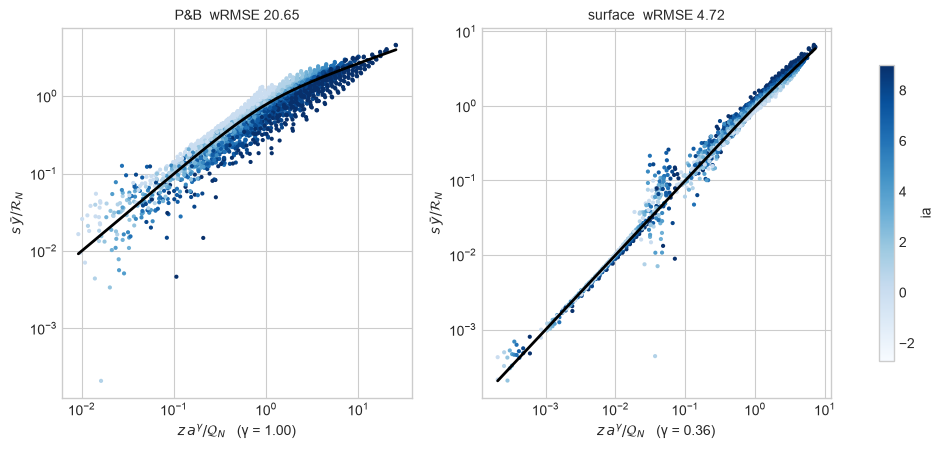

In [6]:
def plot_collapse(fit_list, cells, titles=None, colour='ia'):
    fig, axes = plt.subplots(1, len(fit_list), figsize=(6.2 * len(fit_list), 4.8), squeeze=False)
    for ax, fit, title in zip(axes[0], fit_list, titles or [None] * len(fit_list)):
        f = folded(fit, cells)
        f = f.loc[(f['x'] > 0) & (f['y'] > 0)]
        c = f[colour].to_numpy()
        sc = ax.scatter(f['x'], f['y'], c=c, cmap='Blues' if colour == 'ia' else 'viridis',
                        vmin=c.min() - 0.3 * (c.max() - c.min()), s=9, edgecolors='none')
        grid = np.geomspace(f['x'].min(), f['x'].max(), 400)
        ax.plot(grid, pb_shape(grid, fit.alpha, fit.beta), color='k', lw=2)
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_xlabel(rf'$z\,a^{{\gamma}}/\mathcal{{Q}}_N$   (γ = {fit.gamma:.2f})')
        ax.set_ylabel(r'$s\,\bar y/\mathcal{R}_N$')
        ax.set_title(f'{title or ""}  wRMSE {weighted_rmse(fit, cells):.2f}', fontsize=10)
    fig.colorbar(sc, ax=axes[0], shrink=0.8, label=colour)
    plt.show()


plot_collapse([fits['P&B (γ=1)'], fits['activity surface (γ free)']], cells, ['P&B', 'surface'])

## 3. Profile of the fit in γ

Fix γ on a grid and refit everything else. The curvature around the minimum shows how sharply γ is
identified (compare with the month-block bootstrap interval 0.33–0.39 in the redo).

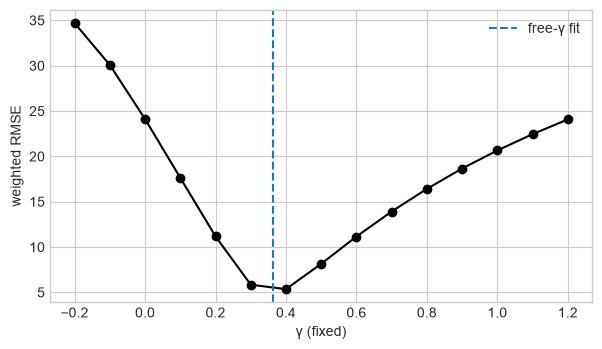

,gamma,weighted_rmse,alpha,beta
0,-0.2000,34.6929,5.8947,5.0000
1,-0.1000,30.0805,8.0000,4.9993
2,0.0000,24.1112,1.7349,0.1985
3,0.1000,17.6315,1.2618,0.0815
4,0.2000,11.1784,1.2522,0.0526
5,0.3000,5.8469,1.2834,0.0845
6,0.4000,5.3566,3.8285,0.1391
7,0.5000,8.1502,2.9374,0.2443
8,0.6000,11.1556,2.3944,0.3365
9,0.7000,13.9169,2.0631,0.4221


In [7]:
GAMMA_GRID = np.round(np.arange(-0.2, 1.21, 0.1), 2)

profile, previous = [], fits['activity surface (γ free)']
for g in GAMMA_GRID:
    f = fit_activity_surface(cells, gamma=float(g), n_starts=2, initial=previous)
    profile.append({'gamma': g, 'weighted_rmse': weighted_rmse(f, cells), 'alpha': f.alpha, 'beta': f.beta})
profile = pd.DataFrame(profile)

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(profile['gamma'], profile['weighted_rmse'], marker='o', color='k')
ax.axvline(fits['activity surface (γ free)'].gamma, ls='--', color='tab:blue', label='free-γ fit')
ax.set_xlabel('γ (fixed)'); ax.set_ylabel('weighted RMSE'); ax.legend()
plt.show()
profile

## 4. Separate fits by N

Each N gets its own α, β, γ. γ rising with N means activity's role shrinks at longer aggregation scales
(the redo found 0.33 at N=100 to 0.65 at N=16,000).

model,P&B (γ=1),activity surface (γ free),imbalance ratio (γ=0)
n_events,,,
100,45.3365,8.6007,50.3939
250,27.3634,3.4005,29.8506
500,18.2296,2.7483,22.0395
1000,12.0864,2.3222,17.2191
2000,8.0806,2.0306,13.7376
4000,5.5031,1.7807,10.9862
8000,3.8605,1.5224,8.7761
16000,2.8171,1.5008,6.7656


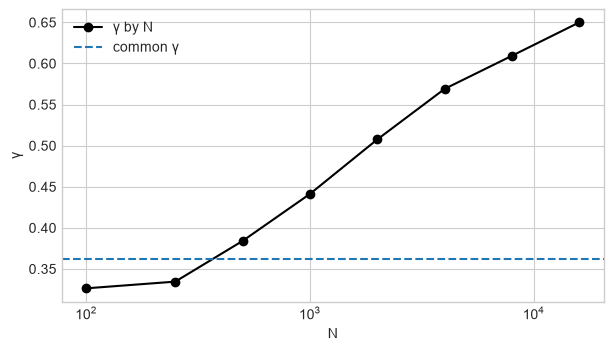

In [8]:
by_n = []
for n in N_USE:
    sub = cells.loc[cells['n_events'] == n]
    for name, g in MODELS.items():
        f = fit_activity_surface(sub, gamma=g, n_starts=4)
        by_n.append({'n_events': n, 'model': name, 'gamma': f.gamma, 'alpha': f.alpha, 'beta': f.beta,
                     'weighted_rmse': weighted_rmse(f, sub)})
by_n = pd.DataFrame(by_n)
display(by_n.pivot(index='n_events', columns='model', values='weighted_rmse'))

surf = by_n.loc[by_n['model'] == 'activity surface (γ free)']
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(surf['n_events'], surf['gamma'], marker='o', color='k', label='γ by N')
ax.axhline(fits['activity surface (γ free)'].gamma, ls='--', color='tab:blue', label='common γ')
ax.set_xscale('log'); ax.set_xlabel('N'); ax.set_ylabel('γ'); ax.legend()
plt.show()

## 5. Sub-periods

Refit on any month window (cuts stay the full-sample ones). Change `WINDOWS` to explore, e.g. single
quarters or the 2022-11 FTX month.

In [9]:
WINDOWS = [(f'{y}-01', f'{y}-12' if y < 2026 else '2026-08') for y in range(2021, 2027)]

period = []
for start, end in WINDOWS:
    c = cells_for(start, end, n_values=N_USE)
    f = fit_models(c, n_starts=4)
    s = summary(f, c)
    period.append({'window': f'{start}..{end}', 'gamma': s.loc['activity surface (γ free)', 'gamma'],
                   **{f'wRMSE {k}': v for k, v in s['weighted_rmse'].items()}})
period = pd.DataFrame(period).set_index('window')
period

,gamma,wRMSE P&B (γ=1),wRMSE imbalance ratio (γ=0),wRMSE activity surface (γ free)
window,,,,
2021-01..2021-12,0.3908,9.0189,11.3278,2.8098
2022-01..2022-12,0.4015,9.1519,12.2047,2.3353
2023-01..2023-12,0.4931,7.6291,14.8256,2.2166
2024-01..2024-12,0.2672,10.9169,8.9155,2.7505
2025-01..2025-12,0.2303,11.3224,7.7111,3.0027
2026-01..2026-08,0.2087,10.0755,6.4232,3.0643


## 6. Where does the surface still miss?

Standard-error-weighted residuals of the common surface on the (z bin × a bin) grid for one N, sides folded
(mean of $s\cdot$residual over the two sides). Red = data above the surface. A systematic pattern along
the activity axis says $a^{\gamma}$ is not the right functional form for activity.

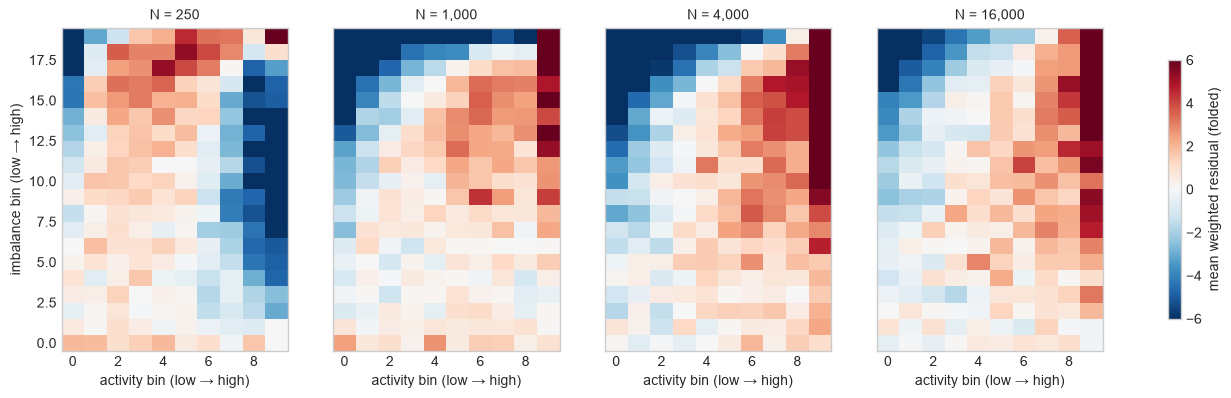

In [10]:
def residual_grid(fit, cells, n):
    sub = cells.loc[cells['n_events'] == n].copy()
    sigma = _clipped_sigma(cells)[(cells['n_events'] == n).to_numpy()]
    sub['wres'] = sub['side'] * (sub['mean_y'] - fit.predict(sub)) / sigma
    return sub.groupby(['iz', 'ia'])['wres'].mean().unstack('ia')


fit = fits['activity surface (γ free)']
show_n = [n for n in (250, 1000, 4000, 16000) if n in N_USE]
fig, axes = plt.subplots(1, len(show_n), figsize=(4.2 * len(show_n), 4.2), squeeze=False, sharey=True)
lim = 6
for ax, n in zip(axes[0], show_n):
    grid = residual_grid(fit, cells, n)
    im = ax.imshow(grid.to_numpy(), origin='lower', aspect='auto', cmap='RdBu_r', vmin=-lim, vmax=lim)
    ax.set_title(f'N = {n:,}', fontsize=10); ax.set_xlabel('activity bin (low → high)')
    ax.grid(False)
axes[0][0].set_ylabel('imbalance bin (low → high)')
fig.colorbar(im, ax=axes[0], shrink=0.8, label='mean weighted residual (folded)')
plt.show()

## 7. The surface itself: response over (imbalance, activity)

For one N: colour = folded cell mean $s\bar y$ (two sides averaged), placed at each cell's geometric-mean
$(a, z)$. Lines = contours of the fitted response. Under the model the contours are straight lines
$\log z + \gamma\log a = \text{const}$, i.e. slope $-\gamma$ in these axes:

- solid: the free-γ surface;
- dashed: P&B (γ = 1, diagonal contours: only $|Q|/V_{24h}$ matters);
- γ = 0 would give horizontal contours (activity irrelevant).

Where the colour bands follow the solid lines rather than the dashed ones, activity enters with γ < 1.
The same contour levels are used for both fits so they can be compared directly.

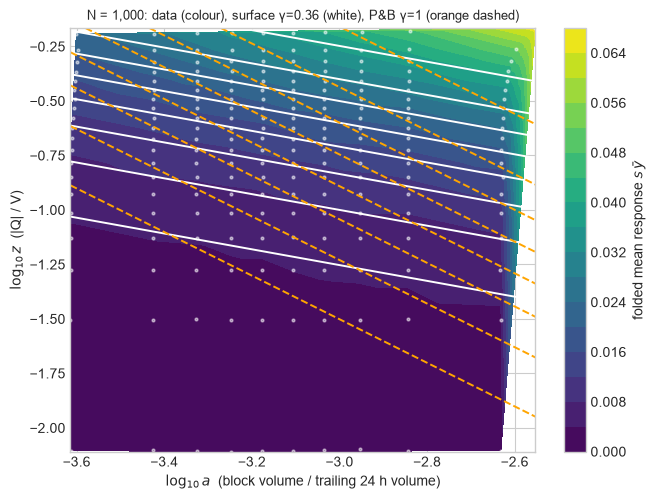

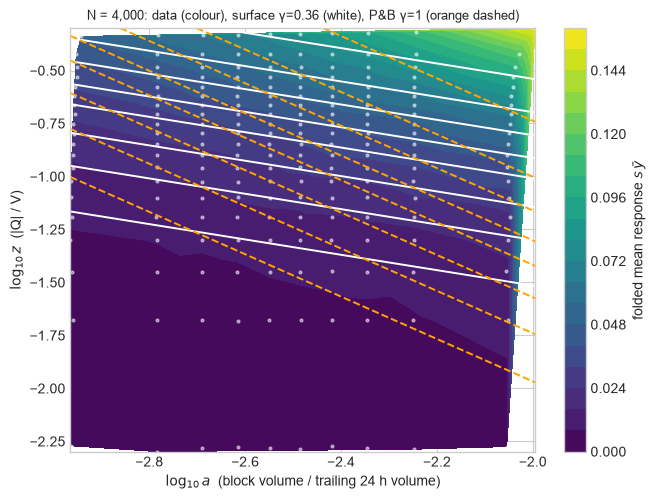

In [11]:
def folded_cells(cells, n):
    sub = cells.loc[cells['n_events'] == n].assign(fy=lambda d: d['side'] * d['mean_y'])
    return sub.groupby(['iz', 'ia'])[['mean_logz', 'mean_loga', 'fy']].mean().reset_index()


def fitted_on_grid(fit, n, log_a, log_z):
    q, r = fit.scales.set_index('n_events').loc[n, ['q_scale', 'r_scale']]
    A, Z = np.meshgrid(log_a, log_z)
    return A, Z, r * pb_shape(np.exp(Z + fit.gamma * A) / q, fit.alpha, fit.beta)


def plot_surface_map(n, fit_main=None, fit_ref=None, levels=8):
    fit_main = fit_main or fits['activity surface (γ free)']
    fit_ref = fit_ref or fits['P&B (γ=1)']
    fc = folded_cells(cells, n)
    log_a = np.linspace(fc['mean_loga'].min(), fc['mean_loga'].max(), 200)
    log_z = np.linspace(fc['mean_logz'].min(), fc['mean_logz'].max(), 200)
    lv = np.quantile(fc['fy'], np.linspace(0.15, 0.95, levels))
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    tc = ax.tricontourf(fc['mean_loga'] / np.log(10), fc['mean_logz'] / np.log(10), fc['fy'], levels=20, cmap='viridis')
    ax.scatter(fc['mean_loga'] / np.log(10), fc['mean_logz'] / np.log(10), s=4, color='white', alpha=0.5)
    for fit, style in ((fit_main, '-'), (fit_ref, '--')):
        A, Z, P = fitted_on_grid(fit, n, log_a, log_z)
        cs = ax.contour(A / np.log(10), Z / np.log(10), P, levels=lv, colors='white' if style == '-' else 'orange',
                        linestyles=style, linewidths=1.4)
    ax.set_xlabel(r'$\log_{10} a$  (block volume / trailing 24 h volume)')
    ax.set_ylabel(r'$\log_{10} z$  (|Q| / V)')
    ax.set_title(f'N = {n:,}: data (colour), surface γ={fit_main.gamma:.2f} (white), P&B γ=1 (orange dashed)', fontsize=9)
    fig.colorbar(tc, ax=ax, label=r'folded mean response $s\,\bar y$')
    plt.show()


for n in [n for n in (1000, 4000) if n in N_USE]:
    plot_surface_map(n)

Optional 3D view for exploring (fitted surface as a mesh, cell means as points). It is hard to read in print —
use the contour map above for the thesis. For a rotatable plot run `%matplotlib widget` first (needs `ipympl`).

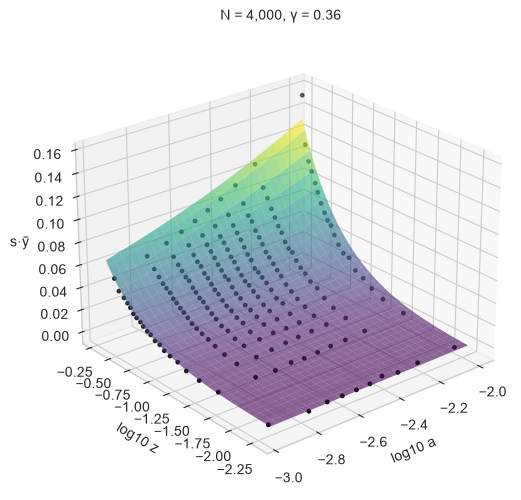

In [12]:
def plot_surface_3d(n, fit=None, elev=25, azim=-130):
    fit = fit or fits['activity surface (γ free)']
    fc = folded_cells(cells, n)
    log_a = np.linspace(fc['mean_loga'].min(), fc['mean_loga'].max(), 60)
    log_z = np.linspace(fc['mean_logz'].min(), fc['mean_logz'].max(), 60)
    A, Z, P = fitted_on_grid(fit, n, log_a, log_z)
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(A / np.log(10), Z / np.log(10), P, cmap='viridis', alpha=0.6, linewidth=0)
    ax.scatter(fc['mean_loga'] / np.log(10), fc['mean_logz'] / np.log(10), fc['fy'], color='k', s=6)
    ax.set_xlabel('log10 a'); ax.set_ylabel('log10 z'); ax.set_zlabel('s·ȳ')
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f'N = {n:,}, γ = {fit.gamma:.2f}', fontsize=10)
    plt.show()


plot_surface_3d(4000 if 4000 in N_USE else N_USE[-1])

## 8. Playground

Ideas to try (each is a few lines with the helpers above):

- `N_USE = (250, 500, 1000, 2000, 4000, 8000, 16000)` — drop the unidentified N = 100 and refit.
- `RESPONSE = 'y'` — raw returns (γ goes negative: activity then proxies yesterday's volatility).
- `SAMPLE = ('2019-10', '2020-12')` — the early period (γ ≈ 0.64 in the redo).
- `N_Z, N_A = 30, 15` — finer grid; check γ is not a binning artefact.
- `plot_collapse([fit_activity_surface(cells, gamma=0.6)], cells)` — look at a collapse by hand.

In [13]:
# Scratch space.